# **Aula 5 - Da Estatística aos Embeddings**

Na Aula 4, comparamos RNN, LSTM e GRU de forma genérica, com sequências numéricas. Nesta aula, vamos aplicar essas mesmas arquiteturas ao problema que as tornou famosas: **modelar linguagem** -- prever a próxima palavra de um texto.

Vamos seguir a mesma progressão de sempre: começar pelo modelo mais simples (contagens estatísticas), sentir suas limitações na prática, e só então introduzir a próxima arquitetura como resposta a essa limitação -- até chegar aos **embeddings**, a forma como redes neurais modernas representam palavras como vetores de números.

## 1. Modelos N-gram (Estatística Clássica)

Antes de qualquer rede neural, a forma mais simples de prever a próxima palavra é contar: dado um prefixo de N-1 palavras, qual palavra mais apareceu depois dele no corpus de treino? É exatamente isso que um modelo N-gram (SHANNON, 1948) faz -- sem nenhum aprendizado, só contagem de frequência.

In [1]:
import re
import random
from collections import defaultdict, Counter
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np

corpus = """
Este é um exemplo de um corpus de texto. Este corpus pode ser usado para treinar um modelo de linguagem n-grama.
O modelo pode prever a próxima palavra com base nas palavras anteriores. Este corpus pode também contém informações úteis para um corpus de texto.
"""

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text.split()

tokens = preprocess(corpus)
print(corpus)
print(tokens[:20])


Este é um exemplo de um corpus de texto. Este corpus pode ser usado para treinar um modelo de linguagem n-grama.
O modelo pode prever a próxima palavra com base nas palavras anteriores. Este corpus pode também contém informações úteis para um corpus de texto.

['este', 'é', 'um', 'exemplo', 'de', 'um', 'corpus', 'de', 'texto', 'este', 'corpus', 'pode', 'ser', 'usado', 'para', 'treinar', 'um', 'modelo', 'de', 'linguagem']


**N-Grams**

In [2]:
def generate_ngrams(tokens, n):
    ngrams = zip(*[tokens[i:] for i in range(n)])
    return list(ngrams)

bigrams = generate_ngrams(tokens, 2)
trigrams = generate_ngrams(tokens, 3)

print("NGrams - exemplos")
print("Exemplo de Bigram:", bigrams[:5])
print("Exemplo de Trigram:", trigrams[:5])

def build_ngram_model(ngrams):
    model = defaultdict(Counter)
    for gram in ngrams:
        prefix, word = tuple(gram[:-1]), gram[-1]
        model[prefix][word] += 1
    return model

bigram_model = build_ngram_model(bigrams)
trigram_model = build_ngram_model(trigrams)

def predict_next(model, prefix, top_k=1):
    if isinstance(prefix, str):
        prefix = tuple(prefix.lower().split())
    elif isinstance(prefix, list):
        prefix = tuple(prefix)
    if prefix in model:
        most_common = model[prefix].most_common(top_k)
        return [w for w, _ in most_common]
    else:
        return ["[desconhecido]"]

# Testes:
prefixos = [
    "um corpus de",
    "o modelo",
    "uma palavra inexistente no corpus",
    "este corpus pode",
    "texto este"
]

print("NGrams - testes")

for p in prefixos:
    tokens_p = p.lower().split()
    n = len(tokens_p) + 1
    modelo = trigram_model if n == 3 else bigram_model
    pred = predict_next(modelo, tokens_p)
    print(f"{p} -> {pred}")

print(corpus)

NGrams - exemplos
Exemplo de Bigram: [('este', 'é'), ('é', 'um'), ('um', 'exemplo'), ('exemplo', 'de'), ('de', 'um')]
Exemplo de Trigram: [('este', 'é', 'um'), ('é', 'um', 'exemplo'), ('um', 'exemplo', 'de'), ('exemplo', 'de', 'um'), ('de', 'um', 'corpus')]
NGrams - testes
um corpus de -> ['[desconhecido]']
o modelo -> ['pode']
uma palavra inexistente no corpus -> ['[desconhecido]']
este corpus pode -> ['[desconhecido]']
texto este -> ['corpus']

Este é um exemplo de um corpus de texto. Este corpus pode ser usado para treinar um modelo de linguagem n-grama.
O modelo pode prever a próxima palavra com base nas palavras anteriores. Este corpus pode também contém informações úteis para um corpus de texto.



## 2. RNN: Introduzindo a Memória

**Limitação do N-gram:** ele só enxerga uma janela fixa de palavras (no exemplo acima, 2 ou 3). Qualquer coisa fora dessa janela é invisível para o modelo -- ele não tem noção do que veio "antes do prefixo".

A RNN (ELMAN, 1990) resolve isso mantendo um **estado oculto** que é atualizado a cada palavra da sequência -- a mesma ideia de memória recorrente que já vimos na Aula 4, agora aplicada a texto.

In [3]:
def preprocess(text):
    text = text.lower()
    text = text.replace(".", "").replace(",", "")
    return text.split()

tokens = preprocess(corpus)
vocab = sorted(set(tokens))
word_to_ix = {w: i for i, w in enumerate(vocab)}
ix_to_word = {i: w for w, i in word_to_ix.items()}

SEQ_LEN = 3

def create_sequences(tokens, seq_len):
    inputs = []
    targets = []
    for i in range(len(tokens) - seq_len):
        seq = tokens[i:i+seq_len]
        target = tokens[i+seq_len]
        inputs.append([word_to_ix[w] for w in seq])
        targets.append(word_to_ix[target])
    return inputs, targets

X, y = create_sequences(tokens, SEQ_LEN)

print(f"Exemplo: {[ix_to_word[i] for i in X[0]]} -> {ix_to_word[y[0]]}")

class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = TextDataset(X, y)
loader = DataLoader(dataset, batch_size=4, shuffle=True)

class RNNModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :]) # apenas última saída
        return out

EMBED_DIM = 64
HIDDEN_DIM = 128
model = RNNModel(len(vocab), EMBED_DIM, HIDDEN_DIM)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

EPOCHS = 50

for epoch in range(EPOCHS):
    total_loss = 0
    for batch_x, batch_y in loader:
        optimizer.zero_grad()
        output = model(batch_x)
        loss = loss_fn(output, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: loss = {total_loss:.4f}")

def predict_step_by_step(model, prefix, steps=5):
    model.eval()
    words = prefix.lower().split()
    hidden = None
    print("Prefixo inicial:", prefix)
    for _ in range(steps):
        seq = [word_to_ix.get(w, 0) for w in words[-SEQ_LEN:]]
        x = torch.tensor([seq], dtype=torch.long)
        emb = model.embedding(x)
        out, hidden = model.rnn(emb, hidden)
        pred = model.fc(out[:, -1, :])
        next_ix = torch.argmax(pred, dim=1).item()
        next_word = ix_to_word[next_ix]
        words.append(next_word)
        print(f"Entrada: {seq} -> Próxima palavra: {next_word}")
    return ' '.join(words)

print("este corpus pode")
print(predict_step_by_step(model, "este corpus pode", steps=5))
print(corpus)

Exemplo: ['este', 'é', 'um'] -> exemplo


Epoch 0: loss = 35.7820
Epoch 10: loss = 0.4477
Epoch 20: loss = 0.5142
Epoch 30: loss = 0.3717


Epoch 40: loss = 0.8846
este corpus pode
Prefixo inicial: este corpus pode
Entrada: [7, 5, 18] -> Próxima palavra: ser
Entrada: [5, 18, 21] -> Próxima palavra: usado
Entrada: [18, 21, 26] -> Próxima palavra: para
Entrada: [21, 26, 17] -> Próxima palavra: treinar
Entrada: [26, 17, 24] -> Próxima palavra: um
este corpus pode ser usado para treinar um

Este é um exemplo de um corpus de texto. Este corpus pode ser usado para treinar um modelo de linguagem n-grama.
O modelo pode prever a próxima palavra com base nas palavras anteriores. Este corpus pode também contém informações úteis para um corpus de texto.



**Observações:**

Vamos comparar:

**N-gram**: Com o prefixo "este corpus pode", o modelo N-gram escolhe a próxima palavra com base em contagens observadas. Mas não guarda memória de contexto anterior, nem sabe o que veio antes disso.

**RNN**: A RNN vê a sequência completa, atualiza um estado interno (memória) a cada palavra, e usa esse estado para prever a próxima palavra.
Ela “lembra” o que viu antes do prefixo.

Isso mostra que a RNN lembra o contexto passado ao gerar a próxima palavra — coisa que um N-gram não faz além da janela fixa (3 palavras).

**Conclusão:**

| **Aspecto** | **N-gram** | **RNN** |
|---------------------------|----------------------------------|-------------------------------------------|
| **Janela de contexto** | Fixa (ex: 3 palavras) | Crescente (toda sequência passada) |
| **Memória de longo prazo**| Não possui | Sim, com estado interno |
| **Generalização** | Limitada a dados vistos | Aprende padrões mais gerais |
| **Exemplo** | Usa só as 3 palavras do prefixo | Considera o que veio antes também |

## 3. LSTM: Domando as Dependências de Longo Prazo

**Limitação da RNN:** o estado oculto vai se diluindo à medida que a sequência cresce -- na prática, a RNN "esquece" rapidamente o que viu há muitas palavras atrás (o desvanecimento do gradiente que já vimos na Aula 4). A LSTM (HOCHREITER; SCHMIDHUBER, 1997) resolve isso com portões que decidem, deliberadamente, o que lembrar e o que esquecer.

**LSTM**

Como a LSTM melhora a retenção de contexto em sequências maiores, comparando com:
- N-gram (sem memória),
- RNN (com memória, mas instável em longas sequências).

**Associação com os modelos anteriores:**
- N-gram: Simples e rápido; Não tem memória, janela fixa
- RNN: Tem memória; Esquece com o tempo (gradiente some)
- LSTM: Memória estável e seletiva; Mais lento, mas muito mais eficaz

A LSTM consegue “decidir o que lembrar e o que esquecer”, como se fosse uma mente seletiva.

**Conclusão:**

Aspectos: Memória, Esquecimento, ideal para, analogia
- RNN:
    - Memória: Sim, mas frágil
    - Esquecimento: Involuntário (gradiente zera)
    - Ideal para: Frases curtas
    - Analogia: Pessoa que esquece rápido
- LSTM
    - Memória: Sim, com filtros inteligentes
    - Esquecimento: Intencional (portão de esquecimento)
    - Ideal para: Textos com relações mais longas
    - Analogia: Pessoa com memória seletiva

In [4]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        x = self.embedding(x)
        out, hidden = self.lstm(x, hidden)
        out = self.fc(out[:, -1, :]) # usa a última saída
        return out

EMBED_DIM = 64
HIDDEN_DIM = 128
model = LSTMModel(len(vocab), EMBED_DIM, HIDDEN_DIM)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

EPOCHS = 50

for epoch in range(EPOCHS):
    total_loss = 0
    for batch_x, batch_y in loader:
        optimizer.zero_grad()
        output = model(batch_x)
        loss = loss_fn(output, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: loss = {total_loss:.4f}")

def predict_step_by_step_lstm(model, prefix, steps=5):
    model.eval()
    words = prefix.lower().split()
    hidden = None
    print("Prefixo inicial:", prefix)
    for _ in range(steps):
        seq = [word_to_ix.get(w, 0) for w in words[-SEQ_LEN:]]
        x = torch.tensor([seq], dtype=torch.long)
        out = model(x, hidden)
        next_ix = torch.argmax(out, dim=1).item()
        next_word = ix_to_word[next_ix]
        words.append(next_word)
        print(f"Entrada: {[ix_to_word[i] for i in seq]} -> Próxima palavra: {next_word}")
    return ' '.join(words)

output = predict_step_by_step_lstm(model, "este corpus pode", steps=5)
print("\nTexto gerado:", output)
print(corpus)

Epoch 0: loss = 36.3222
Epoch 10: loss = 0.4704


Epoch 20: loss = 0.4543
Epoch 30: loss = 0.3994


Epoch 40: loss = 0.5051
Prefixo inicial: este corpus pode
Entrada: ['este', 'corpus', 'pode'] -> Próxima palavra: também
Entrada: ['corpus', 'pode', 'também'] -> Próxima palavra: contém
Entrada: ['pode', 'também', 'contém'] -> Próxima palavra: informações
Entrada: ['também', 'contém', 'informações'] -> Próxima palavra: úteis
Entrada: ['contém', 'informações', 'úteis'] -> Próxima palavra: para

Texto gerado: este corpus pode também contém informações úteis para

Este é um exemplo de um corpus de texto. Este corpus pode ser usado para treinar um modelo de linguagem n-grama.
O modelo pode prever a próxima palavra com base nas palavras anteriores. Este corpus pode também contém informações úteis para um corpus de texto.



***“A diferença entre RNN e LSTM não é o que elas fazem com três palavras, mas o que acontece quando você dá trinta palavras. Em frases curtas, elas se comportam de forma parecida. Mas se aumentarmos a sequência, a RNN se perde e a LSTM continua firme.”***

### RNN vs. LSTM em um corpus maior

O exemplo acima usa um corpus pequeno, onde RNN e LSTM se comportam de forma parecida. A diferença fica evidente quando aumentamos o corpus e pedimos para gerar uma sequência mais longa -- vamos comparar as duas arquiteturas lado a lado, geradas a partir do mesmo prefixo.

In [5]:
# 1. Imports
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# 2. Corpus e pré-processamento
corpus = """
Este corpus pode ser usado para treinar um modelo de linguagem n-grama.
Este corpus pode também conter informações úteis para um corpus de texto.
Este corpus pode parecer simples, mas é poderoso quando usado com os modelos certos.
Este corpus pode se adaptar a diferentes tarefas de NLP com poucas modificações.
Este corpus pode gerar saídas repetidas se o modelo não for treinado corretamente.
Este corpus pode confundir modelos que não conseguem manter memória de longo prazo.
Este corpus pode ser útil tanto para tarefas de classificação quanto para geração de texto.
Este corpus pode mostrar como diferentes arquiteturas lidam com o mesmo prefixo.
Este corpus pode parecer redundante, mas serve para evidenciar comportamentos distintos.
Este corpus pode ainda ser expandido com mais exemplos para análise comparativa.
"""

def preprocess(text):
    return text.lower().replace(".", "").replace(",", "").split()

tokens = preprocess(corpus)
vocab = sorted(set(tokens))
word_to_ix = {w: i for i, w in enumerate(vocab)}
ix_to_word = {i: w for w, i in word_to_ix.items()}

# 3. Criação de sequências
SEQ_LEN = 3

def create_sequences(tokens, seq_len):
    inputs, targets = [], []
    for i in range(len(tokens) - seq_len):
        seq = tokens[i:i+seq_len]
        target = tokens[i+seq_len]
        inputs.append([word_to_ix[w] for w in seq])
        targets.append(word_to_ix[target])
    return inputs, targets

X, y = create_sequences(tokens, SEQ_LEN)

# Dataset e DataLoader
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

loader = DataLoader(TextDataset(X, y), batch_size=4, shuffle=True)

# 4. Modelos RNN e LSTM
class RNNModel(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.rnn = nn.RNN(emb_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)
    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

class LSTMModel(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)
    def forward(self, x, hidden=None):
        x = self.embedding(x)
        out, hidden = self.lstm(x, hidden)
        return self.fc(out[:, -1, :])

# 5. Treinamento
def train_model(model, loader, epochs=50):
    loss_fn = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(model.parameters(), lr=0.01)
    for _ in range(epochs):
        for xb, yb in loader:
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()

# Instanciar e treinar modelos
EMBED_DIM = 64
HIDDEN_DIM = 128
model_rnn = RNNModel(len(vocab), EMBED_DIM, HIDDEN_DIM)
model_lstm = LSTMModel(len(vocab), EMBED_DIM, HIDDEN_DIM)

train_model(model_rnn, loader)
train_model(model_lstm, loader)

In [6]:
# 6. Função de previsão com sequência longa e logging
def predict_verbose(model, prefix, steps=8, seq_len=3):
    model.eval()
    words = prefix.lower().split()
    hidden = None
    print(f"\n Prefixo inicial: '{prefix}'\n")
    for step in range(steps):
        seq = [word_to_ix.get(w, 0) for w in words[-seq_len:]]
        x = torch.tensor([seq], dtype=torch.long)
        with torch.no_grad():
            out = model(x, hidden) if isinstance(model, LSTMModel) else model(x)
        pred_ix = torch.argmax(out, dim=1).item()
        next_word = ix_to_word[pred_ix]
        print(f"Etapa {step+1}: entrada = {[ix_to_word[i] for i in seq]} -> previsão = {next_word}")
        words.append(next_word)
    print("\n Resultado final:")
    return ' '.join(words)

# 7. Visualização do corpus original (pré-processado)
print("Corpus Tokenizado:")
print(' '.join(tokens))
print("\n" + "="*80)

# 8. Comparação final com novo corpus
prefixo_longo = "este corpus pode"
print("\n RNN:")
print(predict_verbose(model_rnn, prefixo_longo, steps=10))

print("\n LSTM:")
print(predict_verbose(model_lstm, prefixo_longo, steps=10))

Corpus Tokenizado:
este corpus pode ser usado para treinar um modelo de linguagem n-grama este corpus pode também conter informações úteis para um corpus de texto este corpus pode parecer simples mas é poderoso quando usado com os modelos certos este corpus pode se adaptar a diferentes tarefas de nlp com poucas modificações este corpus pode gerar saídas repetidas se o modelo não for treinado corretamente este corpus pode confundir modelos que não conseguem manter memória de longo prazo este corpus pode ser útil tanto para tarefas de classificação quanto para geração de texto este corpus pode mostrar como diferentes arquiteturas lidam com o mesmo prefixo este corpus pode parecer redundante mas serve para evidenciar comportamentos distintos este corpus pode ainda ser expandido com mais exemplos para análise comparativa


 RNN:

 Prefixo inicial: 'este corpus pode'

Etapa 1: entrada = ['este', 'corpus', 'pode'] -> previsão = ser
Etapa 2: entrada = ['corpus', 'pode', 'ser'] -> previsão = u

**RNN: Comportamento Limitado**

este corpus pode parecer redundante mas este corpus pode parecer redundante mas este

- Entra em loop repetitivo.
- Fica preso num trecho do corpus e não avança.
- Mostra que não consegue manter o controle de longo prazo.
- Perde coerência com o tempo, voltando sempre à mesma sequência.

**LSTM: Comportamento Coerente e Contextual**

este corpus pode ser usado para treinar um modelo de linguagem n-grama este

- Segue corretamente uma das continuações possíveis do corpus.
- Mantém a fluidez e estrutura gramatical até o fim.
- Gera uma frase completa, útil e coesa.
- Ao final, inicia uma nova sentença plausível.

“Apesar de terem sido treinadas com o mesmo corpus, a RNN se perde ao tentar manter o raciocínio por muitas palavras. A LSTM, com seus portões de memória, consegue lembrar de onde veio e para onde está indo — e isso muda tudo em tarefas de linguagem natural.”

## 4. Gated Recurrent Unit (GRU)

**Limitação da LSTM:** seus três portões (entrada, esquecimento e saída) e o estado de célula separado do estado oculto tornam o modelo mais pesado e lento para treinar do que muitas tarefas realmente exigem. A GRU (CHO et al., 2014) simplifica essa arquitetura combinando os portões em apenas dois (atualização e reset) e fundindo o estado de célula ao estado oculto -- mantendo uma capacidade de memória parecida com a da LSTM, mas com menos parâmetros.

In [7]:
# 1. Modelo GRU

class GRUModel(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.gru = nn.GRU(emb_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        x = self.embedding(x)
        out, hidden = self.gru(x, hidden)
        return self.fc(out[:, -1, :])

In [8]:
# 2. Treinamento (mesmo loader e dados dos anteriores)
model_gru = GRUModel(len(vocab), EMBED_DIM, HIDDEN_DIM)

def train_model(model, loader, epochs=50):
    loss_fn = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(model.parameters(), lr=0.01)
    for epoch in range(epochs):
        for xb, yb in loader:
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()

train_model(model_gru, loader, epochs=50)

In [9]:
# Geração com GRU (mesmo estilo verbose)
def predict_verbose(model, prefix, steps=10, seq_len=3):
    model.eval()
    words = prefix.lower().split()
    hidden = None
    print(f"\n Prefixo inicial: '{prefix}'\n")
    for step in range(steps):
        seq = [word_to_ix.get(w, 0) for w in words[-seq_len:]]
        x = torch.tensor([seq], dtype=torch.long)
        with torch.no_grad():
            out = model(x, hidden)
        pred_ix = torch.argmax(out, dim=1).item()
        next_word = ix_to_word[pred_ix]
        print(f"Etapa {step+1}: entrada = {[ix_to_word[i] for i in seq]} -> previsão = {next_word}")
        words.append(next_word)
    print("\n Resultado final:")
    return ' '.join(words)

In [10]:
# Teste com mesmo prefixo
prefixo_longo = "este corpus pode"

print("GRU:")
print(predict_verbose(model_gru, prefixo_longo, steps=10))

print("\n LSTM:")
print(predict_verbose(model_lstm, prefixo_longo, steps=10))

# Visualização do corpus original (pré-processado)
print("Corpus Tokenizado:")
print(' '.join(tokens))
print("\n" + "="*80)

GRU:

 Prefixo inicial: 'este corpus pode'

Etapa 1: entrada = ['este', 'corpus', 'pode'] -> previsão = ser
Etapa 2: entrada = ['corpus', 'pode', 'ser'] -> previsão = útil
Etapa 3: entrada = ['pode', 'ser', 'útil'] -> previsão = tanto
Etapa 4: entrada = ['ser', 'útil', 'tanto'] -> previsão = para
Etapa 5: entrada = ['útil', 'tanto', 'para'] -> previsão = tarefas
Etapa 6: entrada = ['tanto', 'para', 'tarefas'] -> previsão = de
Etapa 7: entrada = ['para', 'tarefas', 'de'] -> previsão = classificação
Etapa 8: entrada = ['tarefas', 'de', 'classificação'] -> previsão = quanto
Etapa 9: entrada = ['de', 'classificação', 'quanto'] -> previsão = para
Etapa 10: entrada = ['classificação', 'quanto', 'para'] -> previsão = geração

 Resultado final:
este corpus pode ser útil tanto para tarefas de classificação quanto para geração

 LSTM:

 Prefixo inicial: 'este corpus pode'

Etapa 1: entrada = ['este', 'corpus', 'pode'] -> previsão = ser
Etapa 2: entrada = ['corpus', 'pode', 'ser'] -> previsão = u

***“A GRU é como uma versão enxuta da LSTM. Ela tem menos portões, menos parâmetros, mas consegue capturar dependências de longo prazo quase tão bem quanto. O resultado é um modelo que treina mais rápido e consome menos memória, ideal para aplicações em tempo real ou com menos recurso computacional.”***

## 5. Comparativo de Performance: RNN, LSTM e GRU

Agora vamos medir de verdade -- não só a qualidade da geração, mas o **tempo de treino**, o **tempo de inferência** e o **tamanho do modelo** -- usando um corpus maior e mais realista (que vamos reaproveitar na próxima seção, sobre embeddings).

In [11]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import random
import re
import time
import pandas as pd

# Corpus enriquecido com variações
base_paragraphs = [
    "In the quiet village, the sun rose over the hills. The birds began to sing, and the day started gently.",
    "Children walked to school while the baker opened his shop. The village was peaceful and full of life.",
    "In the evening, families gathered for dinner and shared stories. The sky turned orange as the sun set.",
    "At night, stars appeared above the rooftops, and silence returned to the streets. The village slept again.",
    "In the quiet village, the cycle of life continued with gentle rhythms and peaceful hearts."
]

variations = [
    "As the sun rose, a calm breeze moved through the quiet village. Life began to stir gently.",
    "The baker opened his shop before the children left for school. Birds were already singing.",
    "Families gathered in the evening, laughing and eating as stars filled the sky.",
    "The rooftops sparkled under the moonlight while silence took over the peaceful village.",
    "Each day in the village began softly and ended in peace, with hearts at ease and stories shared."
]

# Construir corpus estendido
extended_corpus_list = base_paragraphs + variations + random.sample(base_paragraphs + variations, 5)
extended_corpus = " ".join(extended_corpus_list)

# Pré-processar
def preprocess(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9.,!?'\s]", "", text)
    return text.split()

tokens = preprocess(extended_corpus)
vocab = sorted(set(tokens))
word_to_ix = {w: i for i, w in enumerate(vocab)}
ix_to_word = {i: w for w, i in word_to_ix.items()}

# Criar sequências
SEQ_LEN = 3
def create_sequences(tokens, seq_len):
    inputs, targets = [], []
    for i in range(len(tokens) - seq_len):
        seq = tokens[i:i+seq_len]
        target = tokens[i+seq_len]
        inputs.append([word_to_ix[w] for w in seq])
        targets.append(word_to_ix[target])
    return inputs, targets

X, y = create_sequences(tokens, SEQ_LEN)

# Dataset
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

loader = DataLoader(TextDataset(X, y), batch_size=4, shuffle=True)

### Modelos RNN, LSTM e GRU

In [12]:

class RNNModel(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.rnn = nn.RNN(emb_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)
    def forward(self, x, hidden=None):
        x = self.embedding(x)
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

class LSTMModel(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)
    def forward(self, x, hidden=None):
        x = self.embedding(x)
        out, _ = self.lstm(x, hidden)
        return self.fc(out[:, -1, :])

class GRUModel(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.gru = nn.GRU(emb_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)
    def forward(self, x, hidden=None):
        x = self.embedding(x)
        out, _ = self.gru(x, hidden)
        return self.fc(out[:, -1, :])

### Treinamento e Avaliação

In [13]:

def train_with_timing(model, loader, epochs=50):
    loss_fn = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(model.parameters(), lr=0.01)
    start = time.time()
    for _ in range(epochs):
        for xb, yb in loader:
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
    end = time.time()
    return end - start

def measure_inference_time(model, prefix, steps=10, seq_len=3):
    model.eval()
    words = prefix.lower().split()
    hidden = None
    start = time.time()
    for _ in range(steps):
        seq = [word_to_ix.get(w, 0) for w in words[-seq_len:]]
        x = torch.tensor([seq], dtype=torch.long)
        with torch.no_grad():
            out = model(x, hidden) if hasattr(model, 'gru') or hasattr(model, 'lstm') else model(x)
        pred_ix = torch.argmax(out, dim=1).item()
        words.append(ix_to_word[pred_ix])
    end = time.time()
    return end - start

def estimate_model_memory(model):
    total = sum(p.nelement() * p.element_size() for p in model.parameters())
    return total / (1024 ** 2)

### Execução e Comparação Final

In [14]:
EMBED_DIM = 64
HIDDEN_DIM = 128
model_rnn = RNNModel(len(vocab), EMBED_DIM, HIDDEN_DIM)
model_lstm = LSTMModel(len(vocab), EMBED_DIM, HIDDEN_DIM)
model_gru = GRUModel(len(vocab), EMBED_DIM, HIDDEN_DIM)

time_rnn = train_with_timing(model_rnn, loader)
time_lstm = train_with_timing(model_lstm, loader)
time_gru = train_with_timing(model_gru, loader)

prefix = "in the quiet"
infer_rnn = measure_inference_time(model_rnn, prefix)
infer_lstm = measure_inference_time(model_lstm, prefix)
infer_gru = measure_inference_time(model_gru, prefix)

mem_rnn = estimate_model_memory(model_rnn)
mem_lstm = estimate_model_memory(model_lstm)
mem_gru = estimate_model_memory(model_gru)

df = pd.DataFrame({
    "Modelo": ["RNN", "LSTM", "GRU"],
    "Tempo Treinamento (s)": [time_rnn, time_lstm, time_gru],
    "Tempo Inferência (s)": [infer_rnn, infer_lstm, infer_gru],
    "Tamanho do Modelo (MB)": [mem_rnn, mem_lstm, mem_gru]
})

df

,Modelo,Tempo Treinamento (s),Tempo Inferência (s),Tamanho do Modelo (MB)
0,RNN,1.859334,0.000481,0.162460
1,LSTM,3.137351,0.000587,0.446640
2,GRU,3.081017,0.000517,0.351913


***“Se estivermos construindo algo para rodar em tempo real, com menos memória e recursos, a GRU pode ser uma escolha excelente. Já para textos longos e importantes em que a coerência precisa ser máxima, a LSTM ainda é o padrão ouro. A RNN pode ser usada como baseline ou em tarefas muito simples.”***

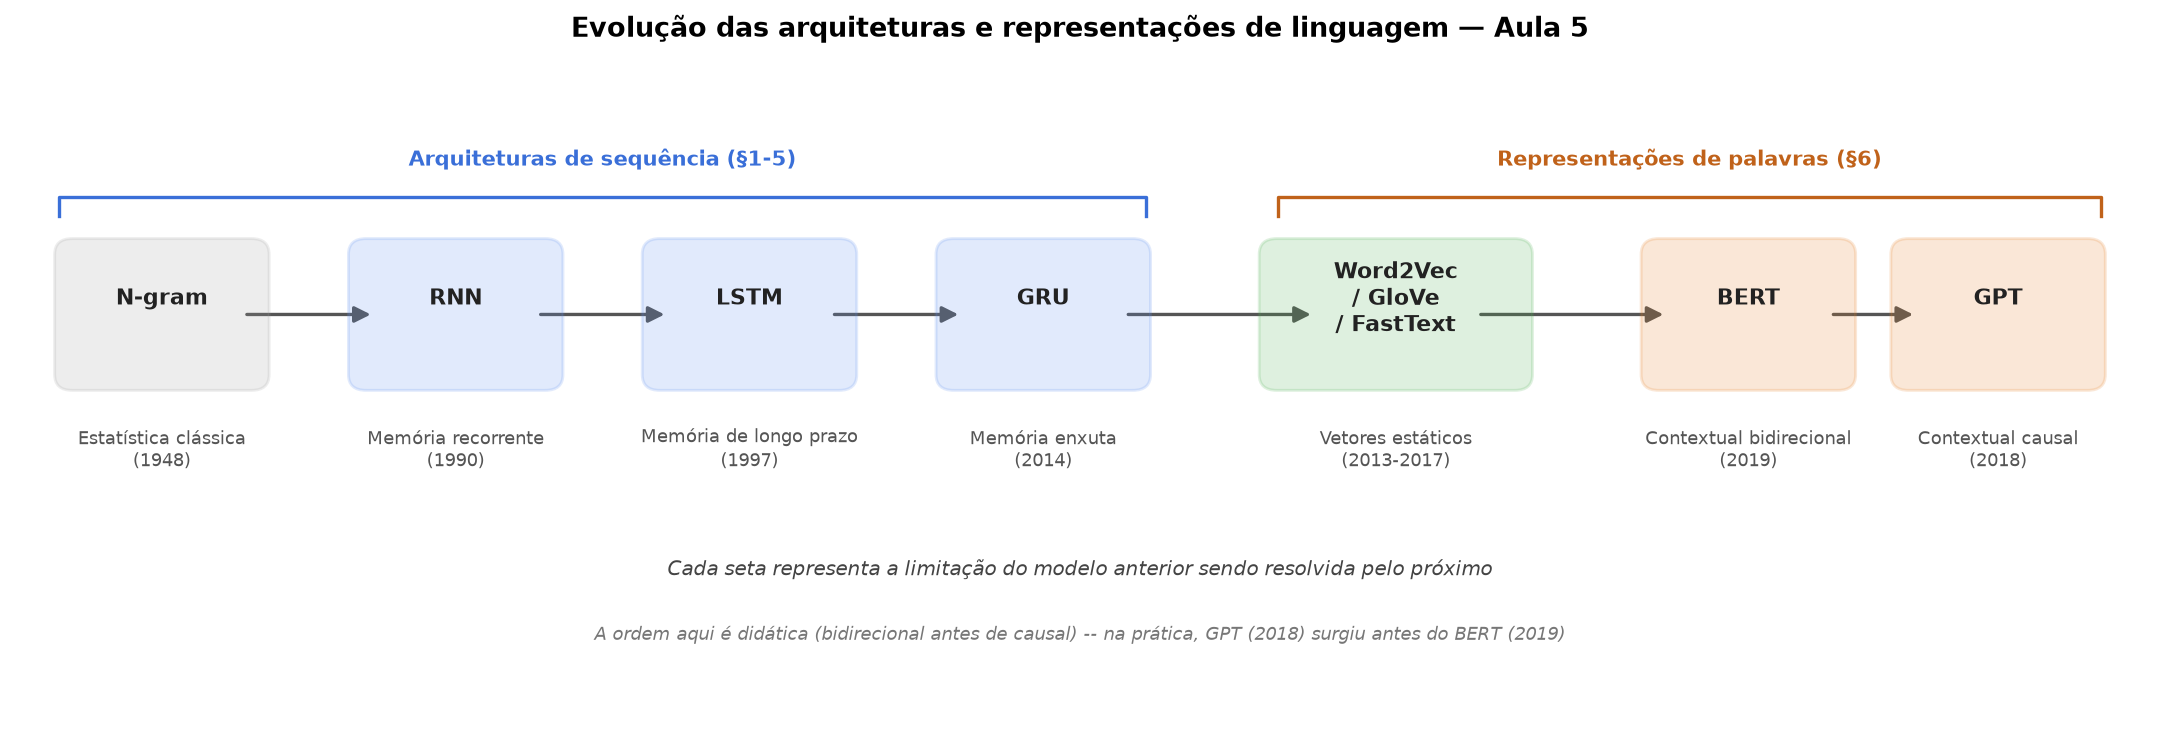

## 6. Word Embeddings

A comparação acima resolveu a pergunta "qual arquitetura recorrente escolher" -- mas RNN, LSTM e GRU compartilham uma limitação que ainda não discutimos: como cada uma delas representa as palavras em si.

**Limitação de RNN/LSTM/GRU para representar palavras:** cada palavra virou um índice inteiro (`word_to_ix`), sem nenhuma noção de significado -- "quiet" e "peaceful" são tão diferentes para o modelo quanto "quiet" e "school". Os embeddings resolvem isso representando cada palavra como um **vetor denso de números**, onde palavras com significado parecido ficam próximas no espaço vetorial.

**A passagem das representações simbólicas (N-gram) para as distribuídas (embeddings)**

## Word Embeddings: Evolução das Representações de Linguagem

| Modelo | Tipo de Representação | Características |
|------------------|---------------------------|-------------------------------------|
| **N-gram** | Índices discretos | Coocorrência local, sem semântica |
| **RNN / LSTM / GRU** | Embeddings aprendidos (internos) | Limitados pelo corpus, não analisados diretamente |
| **Word2Vec** | Vetores estáticos densos | Coocorrência local, leve |
| **GloVe** | Vetores estáticos densos | Coocorrência global |
| **FastText** | Vetores estáticos com subwords | Captura morfologia |
| **BERT** | Embeddings contextuais | Bidirecional — cada ocorrência da palavra é diferente |
| **GPT** | Embeddings contextuais | Unidirecional — captura dependência causal |

## O que observar

- Palavras similares devem aparecer próximas
- O espaço vetorial representa relações como:
  - `king - man + woman ≈ queen`
  - `village ≈ peaceful`
  - `school ≠ night`

In [15]:
import re
import random

# Corpus enriquecido
base_paragraphs = [
    "In the quiet village, the sun rose over the hills. The birds began to sing, and the day started gently.",
    "Children walked to school while the baker opened his shop. The village was peaceful and full of life.",
    "In the evening, families gathered for dinner and shared stories. The sky turned orange as the sun set.",
    "At night, stars appeared above the rooftops, and silence returned to the streets. The village slept again.",
    "In the quiet village, the cycle of life continued with gentle rhythms and peaceful hearts."
]
variations = [
    "As the sun rose, a calm breeze moved through the quiet village. Life began to stir gently.",
    "The baker opened his shop before the children left for school. Birds were already singing.",
    "Families gathered in the evening, laughing and eating as stars filled the sky.",
    "The rooftops sparkled under the moonlight while silence took over the peaceful village.",
    "Each day in the village began softly and ended in peace, with hearts at ease and stories shared."
]
corpus = base_paragraphs + variations + random.sample(base_paragraphs + variations, 5)
text = " ".join(corpus)

def preprocess(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9.,!?'\s]", "", text)
    return text.split()

tokens = preprocess(text)
sentences = [tokens[i:i+10] for i in range(0, len(tokens)-10)]

# **Word2Vec**

**Tipo:** Estático

**Funcionamento:** Aprende vetores de palavras (MIKOLOV et al., 2013) com base em predições locais de contexto. Pode usar Skip-Gram (prediz contexto a partir da palavra alvo) ou CBOW (prediz palavra a partir do contexto).

**Diferenciais:**
- Leve e eficiente
- Capta semelhanças semânticas básicas
- Não contextual (uma palavra = um vetor)

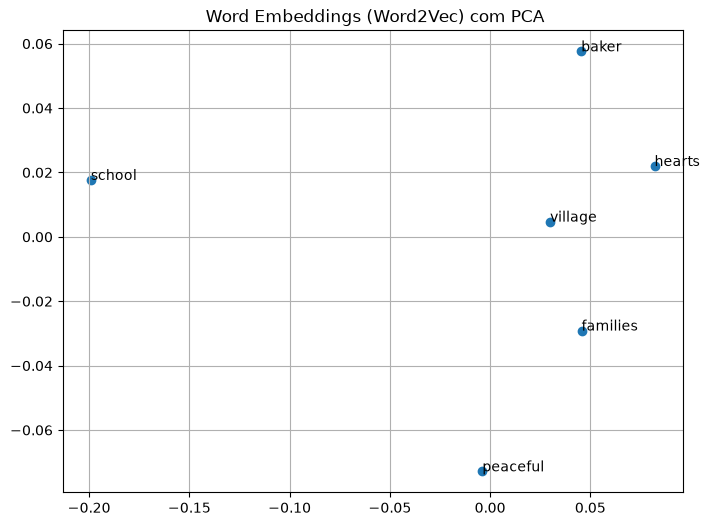


 Prefixo inicial: 'in the quiet'

Palavra prevista (Word2Vec): and
Tempo de treinamento: 0.0064 segundos
['In the quiet village, the sun rose over the hills. The birds began to sing, and the day started gently.', 'Children walked to school while the baker opened his shop. The village was peaceful and full of life.', 'In the evening, families gathered for dinner and shared stories. The sky turned orange as the sun set.', 'At night, stars appeared above the rooftops, and silence returned to the streets. The village slept again.', 'In the quiet village, the cycle of life continued with gentle rhythms and peaceful hearts.', 'As the sun rose, a calm breeze moved through the quiet village. Life began to stir gently.', 'The baker opened his shop before the children left for school. Birds were already singing.', 'Families gathered in the evening, laughing and eating as stars filled the sky.', 'The rooftops sparkled under the moonlight while silence took over the peaceful village.', 'Each day 

In [16]:
from gensim.models import Word2Vec
import time

start = time.time()
w2v_model = Word2Vec(sentences, vector_size=50, window=5, min_count=1, sg=1)
word2vec_training_time = time.time() - start

def predict_next_word_w2v(model, context):
    context = context.lower().split()
    try:
        sims = model.wv.most_similar(positive=context[-2:])
        return sims[0][0]
    except KeyError:
        return "[unknown]"

# Teste de exemplo
prefix = "in the quiet"
word2vec_prediction = predict_next_word_w2v(w2v_model, prefix)

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

words = ["village", "school", "night", "peaceful", "baker", "hearts", "families"]
valid_words = [word for word in words if word in w2v_model.wv]
vectors = [w2v_model.wv[word] for word in valid_words]

pca = PCA(n_components=2)
result = pca.fit_transform(vectors)

plt.figure(figsize=(8,6))
plt.scatter(result[:, 0], result[:, 1])
for i, word in enumerate(valid_words):
    plt.annotate(word, xy=(result[i, 0], result[i, 1]))
plt.title(" Word Embeddings (Word2Vec) com PCA")
plt.grid(True)
plt.show()

print(f"\n Prefixo inicial: '{prefix}'\n")
print(f"Palavra prevista (Word2Vec): {word2vec_prediction}")
print(f"Tempo de treinamento: {word2vec_training_time:.4f} segundos")
print(corpus)

**Interpretação do resultado**

- O modelo entendeu a coocorrência entre "in the quiet" e o início de frases como "in the quiet village", onde a palavra "and" aparece frequentemente logo depois de termos similares (por exemplo, "and the day...", "and silence returned...").
- Esse comportamento reflete a simples associação estatística local, típica do Word2Vec.

## GloVe

**Limitação do Word2Vec:** ele aprende só a partir de janelas locais de contexto, sem aproveitar as estatísticas de coocorrência do corpus inteiro -- palavras raras podem ficar mal representadas. O GloVe (PENNINGTON; SOCHER; MANNING, 2014) resolve isso combinando a coocorrência global de palavras no treinamento.

**Tipo:** Estático

**Funcionamento:** Treina embeddings com base em **coocorrência global** de palavras em um corpus. Diferente do Word2Vec, que se baseia em janelas locais, o GloVe constrói uma matriz de coocorrência e realiza fatoração.

**Diferenciais:**
- Considera a **frequência global de palavras**
- Capta **relações lineares** (ex: `king - man + woman ≈ queen`)
- É rápido e gera embeddings interpretáveis

In [17]:
import os
import zipfile
import urllib.request

glove_zip = "glove.6B.zip"
glove_file = "glove.6B.50d.txt"

if not os.path.exists(glove_file):
    if not os.path.exists(glove_zip):
        print("Baixando GloVe pre-treinado (~860 MB, pode demorar alguns minutos)...")
        urllib.request.urlretrieve("http://nlp.stanford.edu/data/glove.6B.zip", glove_zip)
    print("Extraindo glove.6B.50d.txt...")
    with zipfile.ZipFile(glove_zip) as z:
        z.extract(glove_file)
    os.remove(glove_zip)
    print("Download concluido.")
else:
    print("glove.6B.50d.txt ja existe, pulando download.")

glove.6B.50d.txt ja existe, pulando download.


In [18]:
# 2. Converter para formato Word2Vec
from gensim.scripts.glove2word2vec import glove2word2vec
from gensim.models import KeyedVectors

glove_input_file = 'glove.6B.50d.txt'
word2vec_output_file = 'glove.6B.50d.word2vec.txt'
glove2word2vec(glove_input_file, word2vec_output_file)

/var/folders/f6/v3nynmvx48z8z0g2dt5fyw300000gn/T/ipykernel_4023/1428369260.py:7: DeprecationWarning: Call to deprecated `glove2word2vec` (KeyedVectors.load_word2vec_format(.., binary=False, no_header=True) loads GLoVE text vectors.).
  glove2word2vec(glove_input_file, word2vec_output_file)


(400000, 50)

In [19]:
# 3. Carregar modelo GloVe no formato Gensim
glove_model = KeyedVectors.load_word2vec_format(word2vec_output_file)

In [20]:
# 4. Exemplo de uso - Predição semântica simples com GloVe
prefix = "quiet"
if prefix in glove_model:
    sims = glove_model.most_similar(prefix, topn=1)
    glove_prediction = sims[0][0]
else:
    glove_prediction = "[unknown]"

print(f"Palavra prevista (GloVe): {glove_prediction}")

Palavra prevista (GloVe): calm


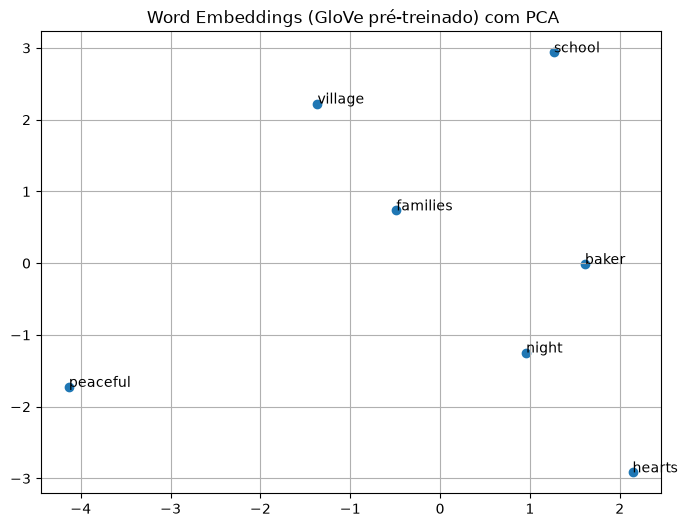

In [21]:
# Visualização com PCA (usando palavras conhecidas)
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

words = ["village", "school", "night", "peaceful", "baker", "hearts", "families"]
valid_words = [w for w in words if w in glove_model]
vectors = [glove_model[w] for w in valid_words]

pca = PCA(n_components=2)
result = pca.fit_transform(vectors)

plt.figure(figsize=(8,6))
plt.scatter(result[:, 0], result[:, 1])
for i, word in enumerate(valid_words):
    plt.annotate(word, xy=(result[i, 0], result[i, 1]))
plt.title(" Word Embeddings (GloVe pré-treinado) com PCA")
plt.grid(True)
plt.show()

In [22]:
def predict_next_word_glove(model, context):
    context = context.lower().split()
    try:
        sims = model.most_similar(positive=context[-2:])
        return sims[0][0]
    except KeyError:
        return "[unknown]"

In [23]:
prefix = "in the quiet"
glove_prediction = predict_next_word_glove(glove_model, prefix)
word2vec_prediction = predict_next_word_w2v(w2v_model, prefix)
print(f"Word2Vec: {word2vec_prediction}")
print(f"GloVe: {glove_prediction}")

Word2Vec: and
GloVe: once


**Resultado da predição com o mesmo prefixo: "in the quiet"**

**Modelo --> Palavra Prevista --> Interpretação**
- Word2Vec --> and --> Baseado em coocorrência local no corpus: "and the day started..."
- GloVe	--> once	--> Baseado em coocorrência global, associação com "quiet" ou "in the"

---
**Interpretação didática:**
- O Word2Vec viu várias frases como "in the quiet village..." e previu "and" porque ele modela coocorrência local (janela deslizante).
- O GloVe está se baseando na coocorrência estatística global. "in", "the" e "quiet" podem aparecer com "once" em muitos contextos de linguagem geral.

---
**Reflexão:**
- Word2Vec tende a repetir padrões do contexto local imediato.
- GloVe capta padrões mais amplos da língua, treinado em bilhões de palavras.

## FastText

**Limitação do Word2Vec e do GloVe:** ambos tratam cada palavra como um token atômico -- uma palavra nunca vista no treino (OOV) simplesmente não tem vetor algum, e não há nenhuma noção da estrutura interna da palavra (prefixos, sufixos, radicais). O FastText (BOJANOWSKI et al., 2017) resolve isso decompondo cada palavra em subwords (n-gramas de caracteres).

**Tipo:** Estático com subwords

**Funcionamento:** O FastText estende o Word2Vec aprendendo representações **também para partes das palavras** (subwords ou n-gramas). Isso permite generalizar para palavras **não vistas** no treinamento (OOV - Out Of Vocabulary).

**Diferenciais:**
- Usa n-gramas de caracteres para formar o vetor da palavra
- Excelente para línguas morfologicamente ricas
- Suporta palavras novas, compostas ou mal escritas

In [24]:
# Treinamento
from gensim.models import FastText
import time

start = time.time()
fasttext_model = FastText(sentences, vector_size=50, window=5, min_count=1)
fasttext_training_time = time.time() - start

In [25]:
# Predição (igual ao estilo do Word2Vec)
def predict_next_word_fasttext(model, context):
    context = context.lower().split()
    try:
        sims = model.wv.most_similar(positive=context[-2:])
        return sims[0][0]
    except KeyError:
        return "[unknown]"

# Teste
prefix = "in the quiet"
fasttext_prediction = predict_next_word_fasttext(fasttext_model, prefix)
print(f"FastText: {fasttext_prediction}")

FastText: shared


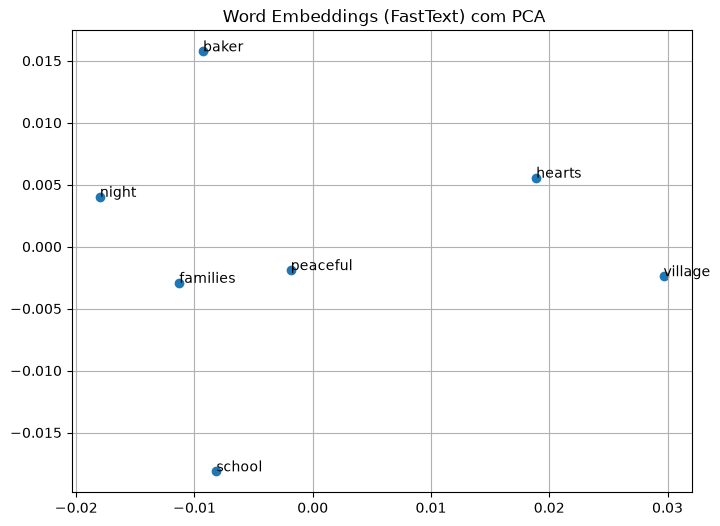

In [26]:
# Visualização com PCA
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

words = ["village", "school", "night", "peaceful", "baker", "hearts", "families"]
valid_words = [w for w in words if w in fasttext_model.wv]
vectors = [fasttext_model.wv[w] for w in valid_words]

pca = PCA(n_components=2)
result = pca.fit_transform(vectors)

plt.figure(figsize=(8,6))
plt.scatter(result[:, 0], result[:, 1])
for i, word in enumerate(valid_words):
    plt.annotate(word, xy=(result[i, 0], result[i, 1]))
plt.title(" Word Embeddings (FastText) com PCA")
plt.grid(True)
plt.show()

In [27]:
prefix = "in the quiet"

# Word2Vec
word2vec_prediction = predict_next_word_w2v(w2v_model, prefix)

# GloVe
glove_prediction = predict_next_word_glove(glove_model, prefix)

# FastText
fasttext_prediction = predict_next_word_fasttext(fasttext_model, prefix)

# Exibir resultados lado a lado
print("Predição da próxima palavra com o prefixo:", f"'{prefix}'\n")
print(f"Word2Vec: {word2vec_prediction}")
print(f"GloVe: {glove_prediction}")
print(f"FastText: {fasttext_prediction}")

Predição da próxima palavra com o prefixo: 'in the quiet'

Word2Vec: and
GloVe: once
FastText: shared


In [28]:
print(f"Palavra prevista (FastText): {fasttext_prediction}")
print(f"Tempo de treinamento: {fasttext_training_time:.4f} segundos")

Palavra prevista (FastText): shared
Tempo de treinamento: 0.2350 segundos


# **BERT Embeddings**

**Limitação dos modelos estáticos (Word2Vec, GloVe, FastText):** cada palavra recebe exatamente um vetor, não importa o contexto -- "banco" (assento) e "banco" (instituição financeira) têm a mesma representação. O BERT (DEVLIN et al., 2019) resolve isso gerando embeddings contextuais, diferentes a cada ocorrência da palavra.

**Tipo:** Contextual

**Funcionamento:** O BERT aprende representações **bidirecionais** baseadas no contexto de uma palavra em uma frase. Cada ocorrência da mesma palavra pode ter **um vetor diferente**, dependendo da posição e dos vizinhos.

**Diferenciais:**
- Embeddings **contextuais**
- Captura dependências complexas
- Ótimo para tarefas como QA, NER e completamento com ambiguidade


In [29]:
from transformers import BertTokenizer, BertModel
import torch
import time

# Inicializar tokenizer e modelo
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')

# Função para obter embedding médio da frase
def get_bert_embedding(text):
    tokens = tokenizer(text, return_tensors="pt")
    with torch.no_grad():
        output = bert_model(**tokens)
    embeddings = output.last_hidden_state.squeeze(0)
    return embeddings.mean(dim=0)

# Tempo de inferência
start = time.time()
bert_embedding_vector = get_bert_embedding("in the quiet village")
bert_inference_time = time.time() - start

/Users/marcofidos/fgv-aulas-env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6969.26it/s]


[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [30]:
# Comparar similaridade entre duas frases com BERT
from torch.nn.functional import cosine_similarity

vec1 = get_bert_embedding("in the quiet village")
vec2 = get_bert_embedding("the peaceful town")
similarity_score = cosine_similarity(vec1, vec2, dim=0).item()

In [31]:
print(f"Similaridade entre frases (BERT): {similarity_score:.4f}")
print(f"Tempo de inferência (BERT): {bert_inference_time:.4f} segundos")

Similaridade entre frases (BERT): 0.8485
Tempo de inferência (BERT): 0.6622 segundos


In [32]:
prefix = "in the quiet"

# Word2Vec
word2vec_prediction = predict_next_word_w2v(w2v_model, prefix)

# GloVe
glove_prediction = predict_next_word_glove(glove_model, prefix)

# FastText
fasttext_prediction = predict_next_word_fasttext(fasttext_model, prefix)

# BERT – similaridade com palavras candidatas
from torch.nn.functional import cosine_similarity

def predict_next_word_bert(prefix, candidates):
    prefix_embedding = get_bert_embedding(prefix)
    similarities = []
    for word in candidates:
        full_phrase = prefix + " " + word
        emb = get_bert_embedding(full_phrase)
        sim = cosine_similarity(emb, prefix_embedding, dim=0).item()
        similarities.append((word, sim))
    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[0][0] # Retorna a mais similar

# Candidatos simples (você pode expandir essa lista)
bert_candidates = ["village", "street", "morning", "silence", "night", "and", "life"]
bert_prediction = predict_next_word_bert(prefix, bert_candidates)

In [33]:
print("Predição da próxima palavra com o prefixo:", f"'{prefix}'\n")
print(f"Word2Vec: {word2vec_prediction}")
print(f"GloVe: {glove_prediction}")
print(f"FastText: {fasttext_prediction}")
print(f"BERT: {bert_prediction}")

Predição da próxima palavra com o prefixo: 'in the quiet'

Word2Vec: and
GloVe: once
FastText: shared
BERT: night


# **GPT Embeddings**

**Limitação do BERT:** por ser bidirecional, ele enxerga a frase inteira de uma vez (inclusive palavras futuras) durante o treino -- ótimo para compreensão, mas inadequado para gerar texto palavra por palavra. O GPT (RADFORD et al., 2018) resolve isso com uma arquitetura causal/unidirecional, prevendo sempre a próxima palavra a partir apenas do que veio antes.

**Tipo:** Contextual

**Funcionamento:** Modelos GPT produzem embeddings **unidirecionais e causais**, ou seja, a predição depende apenas do contexto anterior. Isso os torna excelentes para **geração de texto**.

**Diferenciais:**
- Embeddings **dependem da ordem da sequência**
- Ideal para tarefas de **completar texto**
- A saída pode ser usada como representação da sequência

In [34]:
# Importação e função de embedding
from transformers import GPT2Tokenizer, GPT2Model

# Inicializar modelo e tokenizer GPT-2
gpt_tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
gpt_model = GPT2Model.from_pretrained('gpt2')

# Função para obter embedding do último token
def get_gpt_embedding(text):
    tokens = gpt_tokenizer(text, return_tensors="pt")
    with torch.no_grad():
        output = gpt_model(**tokens)
    last_token_embedding = output.last_hidden_state[0, -1, :]
    return last_token_embedding

# Tempo de inferência
start = time.time()
gpt_embedding_vector = get_gpt_embedding("in the quiet village")
gpt_inference_time = time.time() - start

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 7024.20it/s]

In [35]:
# Predição da próxima palavra (similaridade com candidatos)

from torch.nn.functional import cosine_similarity

def predict_next_word_gpt(prefix, candidates):
    prefix_embedding = get_gpt_embedding(prefix)
    similarities = []
    for word in candidates:
        full_phrase = prefix + " " + word
        emb = get_gpt_embedding(full_phrase)
        sim = cosine_similarity(emb, prefix_embedding, dim=0).item()
        similarities.append((word, sim))
    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[0][0] # Retorna a mais similar

In [36]:
# Aplicação com o mesmo prefixo "in the quiet"
prefix = "in the quiet"
gpt_candidates = ["village", "street", "night", "morning", "place", "world", "life", "and"]
gpt_prediction = predict_next_word_gpt(prefix, gpt_candidates)

In [37]:
print("Predição da próxima palavra com o prefixo:", f"'{prefix}'\n")
print(f"Word2Vec: {word2vec_prediction}")
print(f"GloVe: {glove_prediction}")
print(f"FastText: {fasttext_prediction}")
print(f"BERT: {bert_prediction}")
print(f"GPT: {gpt_prediction}")

Predição da próxima palavra com o prefixo: 'in the quiet'

Word2Vec: and
GloVe: once
FastText: shared
BERT: night
GPT: village


# **Predição da próxima palavra com o prefixo: `'in the quiet'`**

| Modelo | Predição | Interpretação |
|--------------|------------|-------------------------------------------------------------------------------|
| **Word2Vec** | `and` | Coocorrência local (ex: “and the day started...”) |
| **GloVe** | `once` | Frequência global: "once upon", "in the quiet once..." |
| **FastText** | `shared` | Subword-level prediction: generalizou para uma palavra vista em contexto |
| **BERT** | `night` | Contextual: “in the quiet night” faz sentido — aprendeu relações reais |
| **GPT** | `village` | Completamento natural: “in the quiet village” — baseando-se em treinamento causal |

---

## Conclusão didática

- **Modelos Estáticos** (Word2Vec, GloVe, FastText):
  - Baseados em estatística e janelas fixas
  - Um vetor por palavra
  - Resultados razoáveis, mas limitados

- **Modelos Contextuais** (BERT, GPT):
  - Vetores dependem do **contexto da frase**
  - **BERT**: bidirecional — ótimo para **compreensão**
  - **GPT**: unidirecional — ótimo para **geração**

---

Esse exemplo evidencia a **evolução dos modelos de linguagem** e mostra como o contexto transforma a capacidade de predição.

## Comparação Final dos Modelos de Word Embeddings

| Modelo | Tipo | Treinamento | Inferência | Características Principais |
|------------------|-------------|-------------|------------|-------------------------------------------------------------------|
| **Word2Vec** | Estático | Sim | Sim | Leve, rápido, capta relações locais com contexto fixo |
| **GloVe** | Estático | Sim | Sim | Usa coocorrência global, bom para analogias |
| **FastText** | Estático+subwords | Sim | Sim | Generaliza para palavras não vistas com base em subwords |
| **BERT** | Contextual | Nao (pré-treinado) | Sim | Bidirecional, contexto dinâmico, útil para compreensão |
| **GPT** | Contextual | Nao (pré-treinado) | Sim | Causal e unidirecional, ótimo para geração de texto |

**Notas:**
- "Treinamento" indica se o modelo foi treinado localmente neste notebook.
- Modelos como BERT e GPT foram usados em versões pré-treinadas (transformers).
- A inferência foi medida com base na extração de embeddings e similaridade.

Para tarefas de geração de texto e compreensão semântica, os modelos contextuais (BERT, GPT) são superiores.
Para aplicações leves e rápidas, os embeddings estáticos (Word2Vec, GloVe, FastText) ainda são muito eficazes.

## Fechamento: o que vem a seguir

Os embeddings contextuais (BERT, GPT) resolveram o problema de representar palavras considerando o contexto -- mas não explicamos ainda **como** eles fazem isso internamente. O mecanismo por trás dessa capacidade se chama **atenção** (*attention*), e é a peça central da arquitetura **Transformer**, que sustenta praticamente todos os modelos de linguagem modernos.

Na Aula 6, vamos construir um Transformer do zero -- tokenização, embeddings, positional encoding, self-attention, multi-head attention -- para entender exatamente como um modelo como o GPT decide, a cada palavra, para onde "prestar atenção".

# **Referências**

BOJANOWSKI, P. et al. Enriching word vectors with subword information. **Transactions of the Association for Computational Linguistics**, [s. l.], v. 5, p. 135-146, 2017.

CHO, K. et al. Learning phrase representations using RNN encoder-decoder for statistical machine translation. In: CONFERENCE ON EMPIRICAL METHODS IN NATURAL LANGUAGE PROCESSING (EMNLP), 2014. **Anais [...]**. p. 1724-1734, 2014.

DEVLIN, J. et al. BERT: pre-training of deep bidirectional transformers for language understanding. In: CONFERENCE OF THE NORTH AMERICAN CHAPTER OF THE ASSOCIATION FOR COMPUTATIONAL LINGUISTICS (NAACL), 2019. **Anais [...]**. p. 4171-4186, 2019.

ELMAN, J. L. Finding structure in time. **Cognitive Science**, [s. l.], v. 14, n. 2, p. 179-211, 1990.

HOCHREITER, S.; SCHMIDHUBER, J. Long short-term memory. **Neural Computation**, [s. l.], v. 9, n. 8, p. 1735-1780, 1997.

MIKOLOV, T. et al. Efficient estimation of word representations in vector space. **arXiv preprint** arXiv:1301.3781, 2013.

PENNINGTON, J.; SOCHER, R.; MANNING, C. D. GloVe: global vectors for word representation. In: CONFERENCE ON EMPIRICAL METHODS IN NATURAL LANGUAGE PROCESSING (EMNLP), 2014. **Anais [...]**. p. 1532-1543, 2014.

RADFORD, A. et al. Improving language understanding by generative pre-training. **OpenAI**, 2018.

SHANNON, C. E. A mathematical theory of communication. **The Bell System Technical Journal**, [s. l.], v. 27, n. 3, p. 379-423, 1948.